## ** In this notebook we will be looking at the evaluation results of the four different models: UNI, PLIP, DINO & CLIP**

- We will first show tables of the queried images, the number of images retrieved, the total available images and the accuracy score for each model.
- We will look at histograms for accuracy of each of the models
- We will look at scatterplots for accuracy of each of the models 
                                                   
    


### Importing CSV Files From Each Model Evaluation

In [142]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal
sns.set_theme()

In [143]:
unifile = '/Users/aditibelle/Desktop/evaluation_results_uni.csv'
plipfile = '/Users/aditibelle/Desktop/evaluation_results_plip.csv'
dinofile = '/Users/aditibelle/Desktop/evaluation_results_dino.csv'
clipfile = '/Users/aditibelle/Desktop/evaluation_results_clip.csv'


dfu = pd.read_csv(unifile, header=0)
dfp = pd.read_csv(plipfile, header=0)
dfd = pd.read_csv(dinofile, header=0)
dfc = pd.read_csv(clipfile, header=0)

In [144]:
dfu

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,2,5,0.400000
1,1024_02.jpg,2,5,0.400000
2,1024_03.jpg,1,5,0.200000
3,1024_04.jpg,1,5,0.200000
4,1024_05.jpg,2,5,0.400000
5,1353_02.jpg,1,2,0.500000
6,1353_05.jpg,1,2,0.500000
7,2012_01.jpg,1,2,0.500000
8,2012_02.jpg,1,2,0.500000
9,2257_01.jpg,1,5,0.200000


In [145]:
dfp

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,5,0.200000
1,1024_02.jpg,1,5,0.200000
2,1024_03.jpg,1,5,0.200000
3,1024_04.jpg,2,5,0.400000
4,1024_05.jpg,1,5,0.200000
5,1353_02.jpg,1,2,0.500000
6,1353_05.jpg,1,2,0.500000
7,2012_01.jpg,1,2,0.500000
8,2012_02.jpg,1,2,0.500000
9,2257_01.jpg,2,5,0.400000


In [146]:
dfd

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,5,0.200000
1,1024_02.jpg,1,5,0.200000
2,1024_03.jpg,1,5,0.200000
3,1024_04.jpg,1,5,0.200000
4,1024_05.jpg,1,5,0.200000
5,1353_02.jpg,1,2,0.500000
6,1353_05.jpg,1,2,0.500000
7,2012_01.jpg,1,2,0.500000
8,2012_02.jpg,1,2,0.500000
9,2257_01.jpg,4,5,0.800000


In [147]:
dfc

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,5,0.200000
1,1024_02.jpg,1,5,0.200000
2,1024_03.jpg,1,5,0.200000
3,1024_04.jpg,1,5,0.200000
4,1024_05.jpg,1,5,0.200000
5,1353_02.jpg,1,2,0.500000
6,1353_05.jpg,1,2,0.500000
7,2012_01.jpg,1,2,0.500000
8,2012_02.jpg,1,2,0.500000
9,2257_01.jpg,2,5,0.400000


In [148]:
dfu['Model Type'] = 'UNI'
dfp['Model Type'] = 'PLIP'
dfd['Model Type'] = 'DINO'
dfc['Model Type'] = 'CLIP'

In [149]:
combined = pd.concat([dfu, dfp, dfd, dfc], ignore_index=True)

<Axes: xlabel='Model Type', ylabel='Match Accuracy'>

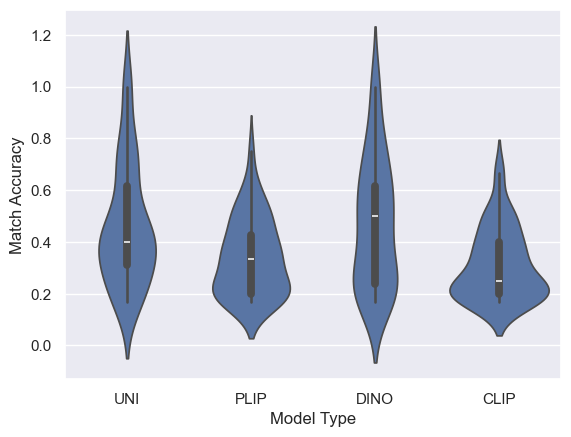

In [150]:
sns.violinplot(x='Model Type', y='Match Accuracy', data=combined)

In [151]:
mean_acc = []

mean_acc.append(dfu["Match Accuracy"].mean())
mean_acc.append(dfp["Match Accuracy"].mean())
mean_acc.append(dfd["Match Accuracy"].mean())
mean_acc.append(dfc["Match Accuracy"].mean())

mean_acc

[0.4606060606136364,
 0.34053030303030307,
 0.47045454545454546,
 0.31136363636363645]

In [152]:
models = ["UNI", "PLIP", "DINO", "CLIP"]
models

['UNI', 'PLIP', 'DINO', 'CLIP']

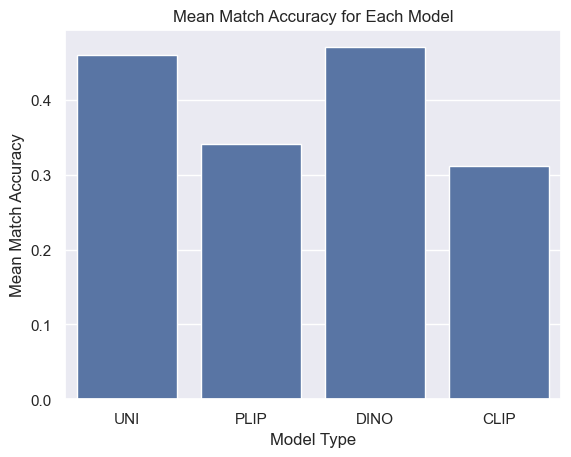

In [153]:
sns.barplot(x = models, y= mean_acc)

plt.xlabel('Model Type')
plt.ylabel('Mean Match Accuracy')
plt.title('Mean Match Accuracy for Each Model')
plt.show()

## **Comparing Baseline vs Augmented evaluation results**

In [154]:
fileunib = '/Users/aditibelle/Desktop/baseline_evaluation_results_uni.csv'
fileunia = '/Users/aditibelle/Desktop/aug1_evaluation_results_uni.csv'

filedinob = '/Users/aditibelle/Desktop/baseline_evaluation_results_dino.csv'
filedinoa = '/Users/aditibelle/Desktop/aug1_evaluation_results_dino.csv'

fileclipb = '/Users/aditibelle/Desktop/baseline_evaluation_results_clip.csv'
fileclipa = '/Users/aditibelle/Desktop/augmentation1_evaluation_results_clip.csv'

fileplipb = '/Users/aditibelle/Desktop/baseline_evaluation_results_plip.csv'
fileplipa = '/Users/aditibelle/Desktop/augmentation1_evaluation_results_plip.csv'


In [155]:
dfub= pd.read_csv(fileunib, header=0)
dfua= pd.read_csv(fileunia, header=0)
dfdb= pd.read_csv(filedinob, header=0)
dfda= pd.read_csv(filedinoa, header=0)
dfcb = pd.read_csv(fileclipb, header=0)
dfca = pd.read_csv(fileclipa, header=0)
dfpb = pd.read_csv(fileplipb, header=0)
dfpa = pd.read_csv(fileplipa, header=0)

In [156]:
dfub

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,1,6,0.166667
5,1024_05.jpg,1,6,0.166667
6,1353_01.PNG,2,5,0.400000
7,1353_02.jpg,1,5,0.200000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [157]:
dfua

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,4,5,0.800000
7,1353_02.jpg,3,5,0.600000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [158]:
dfdb

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,1,6,0.166667
5,1024_05.jpg,1,6,0.166667
6,1353_01.PNG,1,5,0.200000
7,1353_02.jpg,1,5,0.200000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [159]:
dfda

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,2,6,0.333333
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,3,5,0.600000
7,1353_02.jpg,1,5,0.200000
8,1353_03.png,2,5,0.400000
9,1353_04.png,1,5,0.200000


In [160]:
dfcb

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,1,5,0.200000
7,1353_02.jpg,1,5,0.200000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [161]:
dfpb

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,1,5,0.200000
7,1353_02.jpg,1,5,0.200000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [162]:
dfca

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,1,5,0.200000
7,1353_02.jpg,2,5,0.400000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [163]:
dfpa

,Queried Image,Number of Matches Found,Total Available Matches,Match Accuracy
0,1024_01.jpg,1,6,0.166667
1,1024_02.jpg,1,6,0.166667
2,1024_03.jpg,1,6,0.166667
3,1024_04.jpg,1,6,0.166667
4,1024_05.jpeg,2,6,0.333333
5,1024_05.jpg,2,6,0.333333
6,1353_01.PNG,1,5,0.200000
7,1353_02.jpg,2,5,0.400000
8,1353_03.png,1,5,0.200000
9,1353_04.png,1,5,0.200000


In [164]:
dfub['Model Type'] = 'UNI Baseline'
dfua['Model Type'] = 'UNI Aug1'
dfdb['Model Type'] = 'DINO Baseline'
dfda['Model Type'] = 'DINO Aug1'
dfcb['Model Type'] = 'CLIP Baseline'
dfca['Model Type'] = 'CLIP Aug1'
dfpb['Model Type'] = 'PLIP Baseline'
dfpa['Model Type'] = 'PLIP Aug1'

In [165]:
combined2 = pd.concat([dfub, dfua, dfdb, dfda, dfcb, dfca, dfpb, dfpa], ignore_index=True)

<function matplotlib.pyplot.show(close=None, block=None)>

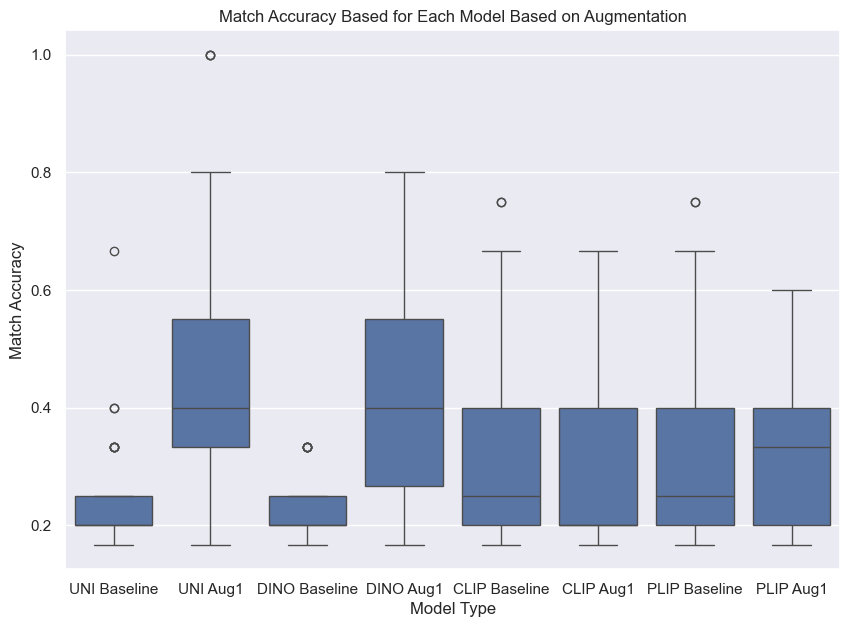

In [166]:
plt.figure(figsize=(10,7))
sns.boxplot(x='Model Type', y='Match Accuracy', data=combined2)
plt.title('Match Accuracy Based for Each Model Based on Augmentation')
plt.show

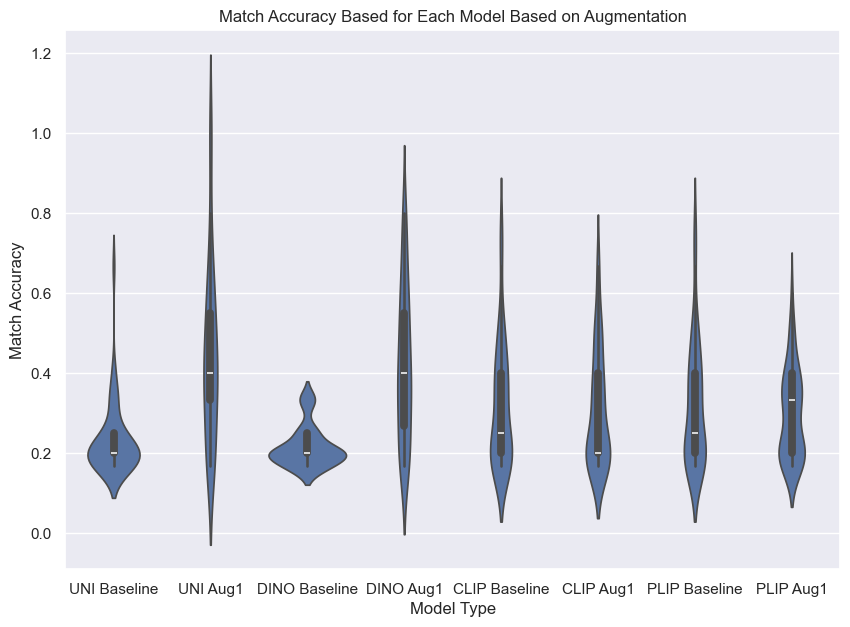

In [167]:
plt.figure(figsize=(10,7))
sns.violinplot(x='Model Type', y='Match Accuracy', data=combined2)
plt.title('Match Accuracy Based for Each Model Based on Augmentation')
plt.show()

In [168]:
mean_acc2 = []

mean_acc2.append(dfub["Match Accuracy"].mean())
mean_acc2.append(dfua["Match Accuracy"].mean())
mean_acc2.append(dfdb["Match Accuracy"].mean())
mean_acc2.append(dfda["Match Accuracy"].mean())
mean_acc2.append(dfcb["Match Accuracy"].mean())
mean_acc2.append(dfca["Match Accuracy"].mean())
mean_acc2.append(dfpb["Match Accuracy"].mean())
mean_acc2.append(dfpa["Match Accuracy"].mean())

mean_acc2

[0.2300653594771242,
 0.43954248366013077,
 0.21568627450980396,
 0.41993464052287577,
 0.3179738562091503,
 0.30686274509803924,
 0.3179738562091503,
 0.2980392156862745]

In [169]:
models2 = ["UNI Baseline", "UNI Aug1", "DINO Baseline", "DINO Aug1", "CLIP Baseline", "CLIP Aug1" , "PLIP Baseline", "PLIP Aug1"]
models2

['UNI Baseline',
 'UNI Aug1',
 'DINO Baseline',
 'DINO Aug1',
 'CLIP Baseline',
 'CLIP Aug1',
 'PLIP Baseline',
 'PLIP Aug1']

In [170]:
colors = ['blue', 'blue', 'red', 'red', 'green', 'green', 'purple', 'purple']

/var/folders/zb/nmzstbx94s75vdk3sm3dvk9w0000gn/T/ipykernel_28839/1976903947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = models2, y= mean_acc2, palette= colors)


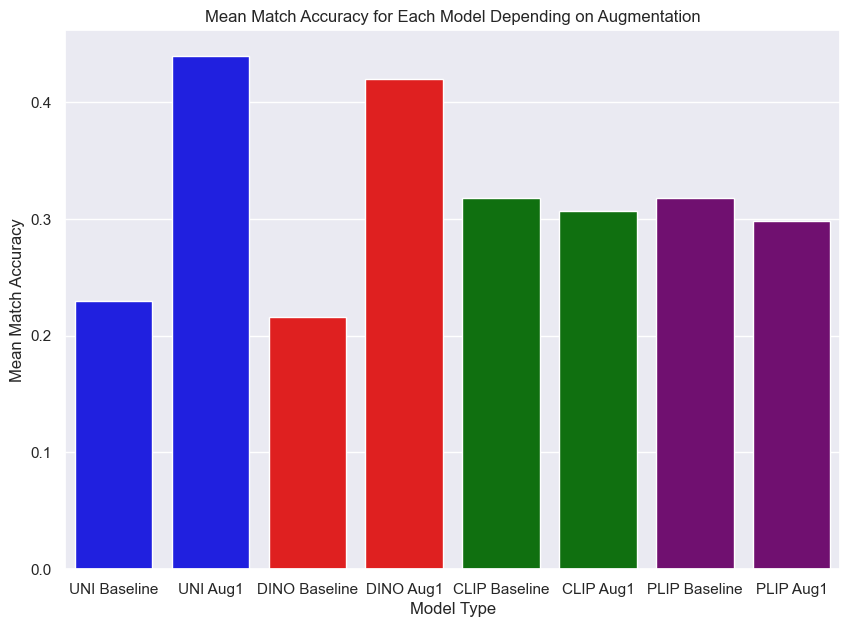

In [171]:
plt.figure(figsize=(10,7))
sns.barplot(x = models2, y= mean_acc2, palette= colors)

plt.xlabel('Model Type')
plt.ylabel('Mean Match Accuracy')
plt.title('Mean Match Accuracy for Each Model Depending on Augmentation')
plt.show()